# ADL 원시 데이터 탐색 (EDA)

**대상 테이블**: `adl_raw_records` — 데이터바우처 지원사업 엑셀 샘플(응급/사망 발생 ADL, 54컬럼).
`scripts/seed_adl_raw.py` 로 적재된 원시 데이터다.

**목적**: AI 이상탐지 모델 설계에 앞서 분포·결측·응급 vs 사망 패턴 차이를 탐색한다.

**접속 방식**: CLAUDE.md 규칙(raw SQL 금지)에 따라 Tortoise ORM(async)으로 조회한다.
Jupyter 는 셀에서 top-level `await` 를 지원한다.

**실행법**: `make notebook` (또는 `uv run jupyter lab notebooks/`) 후 위에서 아래로 전체 셀 실행.
데이터가 없으면 먼저 `uv run python scripts/seed_adl_raw.py` 로 적재한다.

## 1. 환경 설정

노트북은 `notebooks/` 에서 실행되므로 `app.config` 의 `.env`/`.env.local` 해석을 위해
작업 디렉토리를 프로젝트 루트로 옮기고 `sys.path` 에 등록한다.

In [1]:
import os
import sys
from pathlib import Path


def _set_project_root() -> Path:
    """작업 디렉토리를 프로젝트 루트로 이동 (.env.local·app import 해석용, 폴더 생성 아님)."""
    root = Path.cwd()
    if root.name == "notebooks":
        root = root.parent
    os.chdir(root)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    return root


ROOT = _set_project_root()

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# seaborn 테마 적용 후 한글 폰트를 덮어쓴다 (한글 라벨 렌더링).
sns.set_theme(style="whitegrid")
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)

print(f"프로젝트 루트: {ROOT}")

프로젝트 루트: c:\Users\kdwkd\documents\project\salpyeobom\salpyeobom-backend


## 2. DB 연결

`app/database.py` 의 `TORTOISE_ORM` 설정을 그대로 재사용한다. 읽기 전용 분석이므로
`init_db()`(스키마 생성 포함) 대신 `Tortoise.init` 만 호출한다. 셀 재실행 시 중복
초기화를 막기 위해 `Tortoise._inited` 를 확인한다.

In [2]:
from tortoise import Tortoise

from app.config import settings
from app.database import TORTOISE_ORM

if not Tortoise._inited:
    await Tortoise.init(config=TORTOISE_ORM)

# 접속 대상 확인 (호스트/DB명만 출력, 비밀번호 제외)
_url = settings.DATABASE_URL
print("DB 연결 완료:", _url.split("@")[-1] if "@" in _url else _url)

DB 연결 완료: 127.0.0.1:5432/salpyeobom


## 3. 데이터 적재

`AdlRawRecord.all().values()` 로 전체 행을 dict 리스트로 가져와 DataFrame 으로 변환한다.
`aix_h_list`·`temp_list` 같은 JSON 컬럼은 Python `list` 로 복원된다.

In [3]:
from app.models.adl_raw import AdlRawRecord

records = await AdlRawRecord.all().values()
df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(
        "adl_raw_records 가 비어 있습니다. "
        "먼저 adl_raw_ingest.ipynb 로 적재하세요."
    )

print(f"adl_raw_records: {len(df)} 행 × {df.shape[1]} 열")
df.head()

adl_raw_records: 60 행 × 54 열


,id,source_type,care_recipient_id,age,sex,alone,vision,hearing,dosage,district,house_structure,room_no,bath_location,lifeog_date,emergency_date,emergency_record,occurrence_place,on_site,hospital_transfer,hospital_treatment,death_date,death_record,place_code_1_list,aix_1_list,aix_h_list,aix_d,aix_1_eq_0_repeat_count,total_aix_sum,total_aix_inc_ratio,night_aix_ratio,total_age_aix_ratio,sleep_depth_1_list,sleep_start_time_d,sleep_end_time_d,total_sleep_period,total_sleep_aix_ratio,bath_count_d,bath_time_d,bath_nomove_time,bath_count_in_sleep,bath_time_per_count,total_bath_average_count,outgoing_1_list,outgoing_count_d,outgoing_time_d,outgoing_late_night_count_d,outgoing_late_night_time_d,last_outgoing_time,total_outgoing_average_time,total_outgoing_average_count,temp_list,humi_list,illu_list,created_at
0,65,응급,661.0,78.0,F,Y,보통,보통,없음,도시,주택,2.0,옥내,2022-01-03,2022-01-03,09:10 휴대폰 / 부재2회\n09:10 G/W / 요양보호사 / 계단에서 넘어져...,실외,출동,이송,입원,None,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[18, 7, 4, 0, 52, 311, 110, 13, 27, 58, 116, 0...",36.0,0,75.0,-52.0,1828.0,36.0,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",45,694,63.0,70.0,8,161.0,NaN,3,20.0,15.0,"[255, 254, 254, 254, 254, 254, 254, 254, 254, ...",9,444.0,0,0.0,0,375.0,6.0,"[30.0, 30.0, 29.8, 29.6, 29.4, 29.2, 29.1, 29....","[59.7, 59.6, 60.1, 60.4, 60.8, 61.2, 61.4, 61....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 10.0, 18.0...",2026-05-18 23:16:22.083145+00:00
1,66,응급,661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-02,None,NaN,NaN,NaN,NaN,NaN,None,NaN,"[254, 254, 254, 254, 254, 254, 254, 254, 254, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 102, 170, 149, 24, 1, 0, 0,...",25.0,0,73.0,-65.0,0.0,25.0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",38,674,436.0,65.0,11,142.0,NaN,2,12.0,15.0,"[254, 254, 254, 254, 254, 254, 254, 254, 254, ...",11,793.0,1,240.0,0,383.0,7.0,"[28.8, 28.6, 28.4, 28.4, 28.4, 28.3, 28.2, 28....","[65.0, 65.3, 65.3, 65.2, 65.2, 65.3, 65.6, 65....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...",2026-05-18 23:16:22.130890+00:00
2,67,응급,661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,None,NaN,NaN,NaN,NaN,NaN,None,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 22, 41, 0, 233, 1, 0, 68, 51, 7, 0, 0, 52,...",25.0,0,72.0,-65.0,3797.0,25.0,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",33,639,130.0,65.0,10,194.0,NaN,3,19.0,15.0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",8,255.0,0,0.0,0,374.0,7.0,"[27.8, 27.8, 27.7, 27.5, 27.5, 27.4, 27.3, 27....","[68.0, 68.0, 67.9, 67.8, 67.7, 67.6, 67.5, 68....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 11.0, 16.0...",2026-05-18 23:16:22.134892+00:00
3,68,응급,661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-31,None,NaN,NaN,NaN,NaN,NaN,None,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 113, 19, 103, 134, 49, 142, 1, 0, 0, 21...",59.0,0,71.0,-16.0,7959.0,59.0,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",36,572,100.0,81.0,7,220.0,NaN,2,31.0,14.0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",3,349.0,0,0.0,0,379.0,7.0,"[29.2, 29.1, 28.7, 28.5, 28.4, 28.2, 28.0, 27....","[63.9, 64.1, 64.2, 64.0, 64.0, 64.1, 64.3, 65....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 3.0, 8.0, ...",2026-05-18 23:16:22.139891+00:00
4,69,응급,661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-30,None,NaN,NaN,NaN,NaN,NaN,None,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 77, 198, 36, 31, 0, 81, 71, 162, 0, ...",33.0,0,70.0,-52.0,4262.0,33.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, ...",170,549,719.0,75.0,5,14.0,NaN,2,2.0,14.0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",10,367.0,0,0.0,0,389.0,7.0,"[30.2, 29.8, 29.6, 29.3, 29.0, 28.8, 28.5, 28....","[62.9, 62.8, 62.8, 62.8, 63.3, 63.7, 63.8, 64....","[0.

## 4. 데이터 개요 — 분포·결측·타입

In [4]:
print("=== source_type 분포 ===")
display(df["source_type"].value_counts())

print("\n=== 컬럼별 결측률 (%) ===")
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
display(missing[missing > 0].to_frame("결측률(%)"))

print("\n=== dtype 요약 ===")
display(df.dtypes.value_counts())

=== source_type 분포 ===


source_type
응급    30
사망    30
Name: count, dtype: int64


=== 컬럼별 결측률 (%) ===


,결측률(%)
occurrence_place,98.3
on_site,98.3
hospital_transfer,98.3
hospital_treatment,98.3
death_date,98.3
death_record,98.3
emergency_record,98.3
emergency_date,98.3
district,96.7
bath_location,96.7



=== dtype 요약 ===


str                    19
float64                17
object                 11
int64                   6
datetime64[us, UTC]     1
Name: count, dtype: int64

## 5. 기본 정보 — 연령·성별·독거·주거

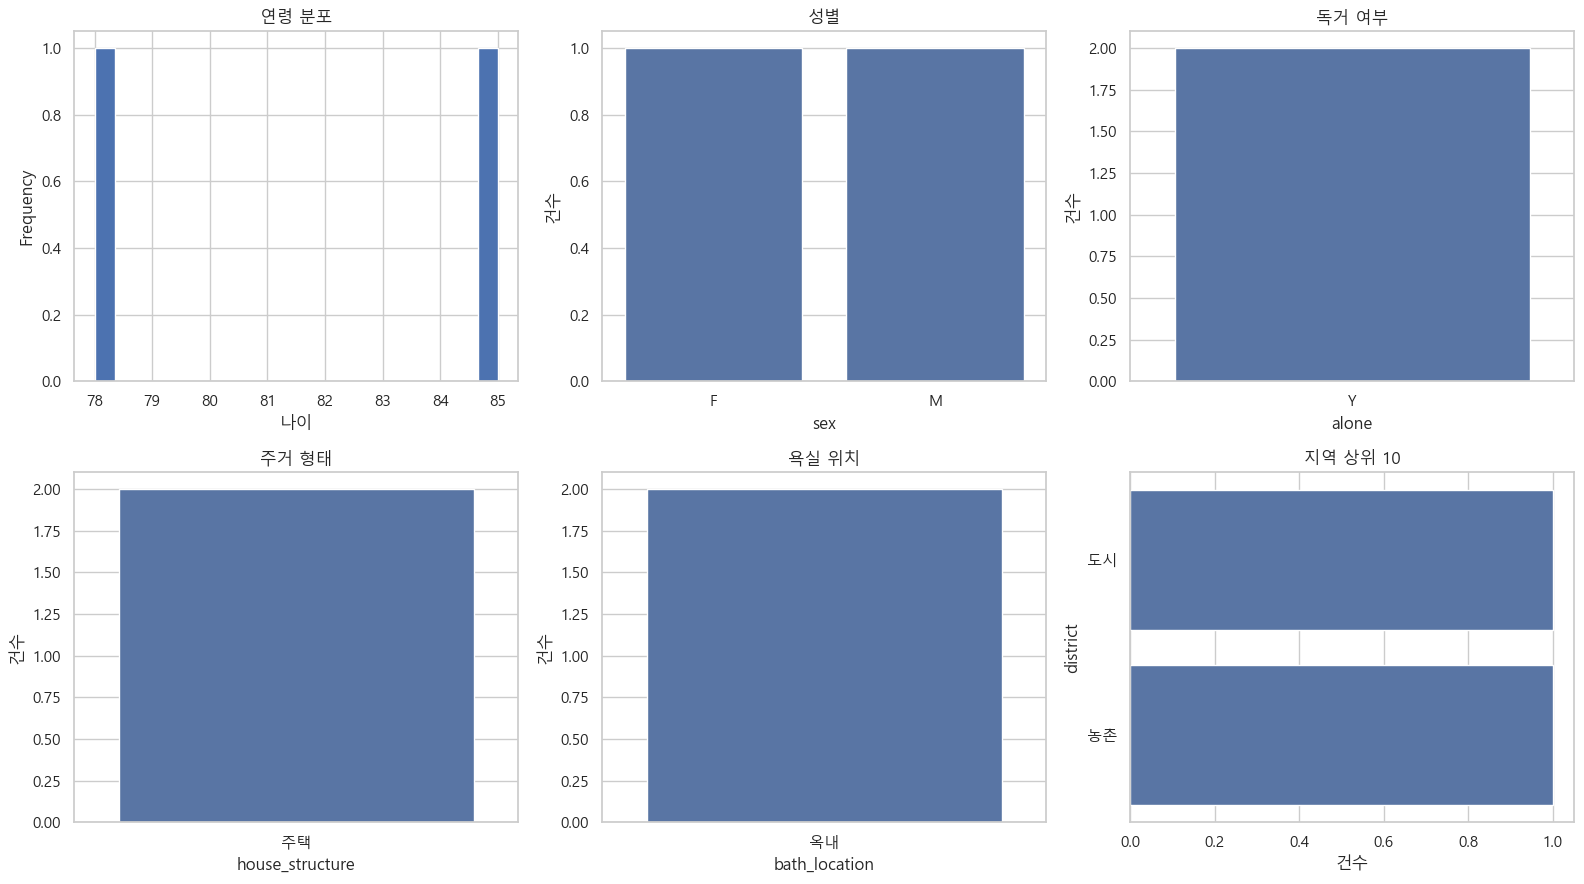

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

df["age"].dropna().plot(
    kind="hist", bins=20, ax=axes[0, 0], edgecolor="white", title="연령 분포"
)
axes[0, 0].set_xlabel("나이")

for ax, col, title in [
    (axes[0, 1], "sex", "성별"),
    (axes[0, 2], "alone", "독거 여부"),
    (axes[1, 0], "house_structure", "주거 형태"),
    (axes[1, 1], "bath_location", "욕실 위치"),
]:
    vc = df[col].value_counts()
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("건수")

vc = df["district"].value_counts().head(10)
sns.barplot(y=vc.index.astype(str), x=vc.values, ax=axes[1, 2])
axes[1, 2].set_title("지역 상위 10")
axes[1, 2].set_xlabel("건수")

plt.tight_layout()
plt.show()

## 6. 이벤트 정보 — 발생 장소·이송·치료 (응급/사망 분리)

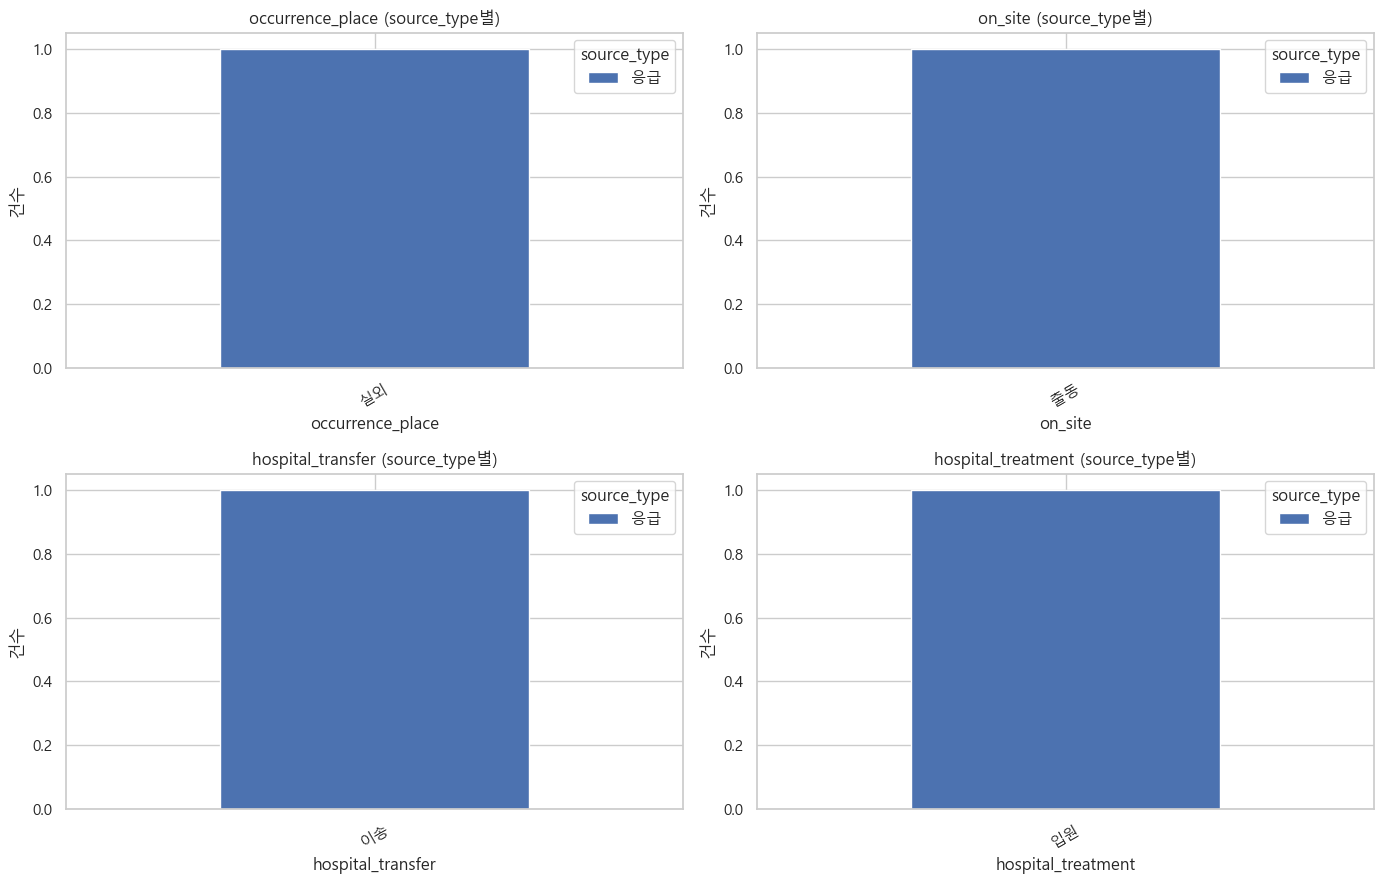

In [6]:
event_cols = ["occurrence_place", "on_site", "hospital_transfer", "hospital_treatment"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, event_cols):
    ct = (
        df.groupby("source_type")[col]
        .value_counts()
        .unstack(0)
        .fillna(0)
    )
    ct.plot(kind="bar", ax=ax)
    ax.set_title(f"{col} (source_type별)")
    ax.set_ylabel("건수")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. AIX 분석 피처 — 응급 vs 사망 비교

`aix_d`(일 단위 활동지수), `total_aix_sum`, `night_aix_ratio`(야간 비중),
`total_aix_inc_ratio`(증가율) 의 그룹별 분포를 본다.

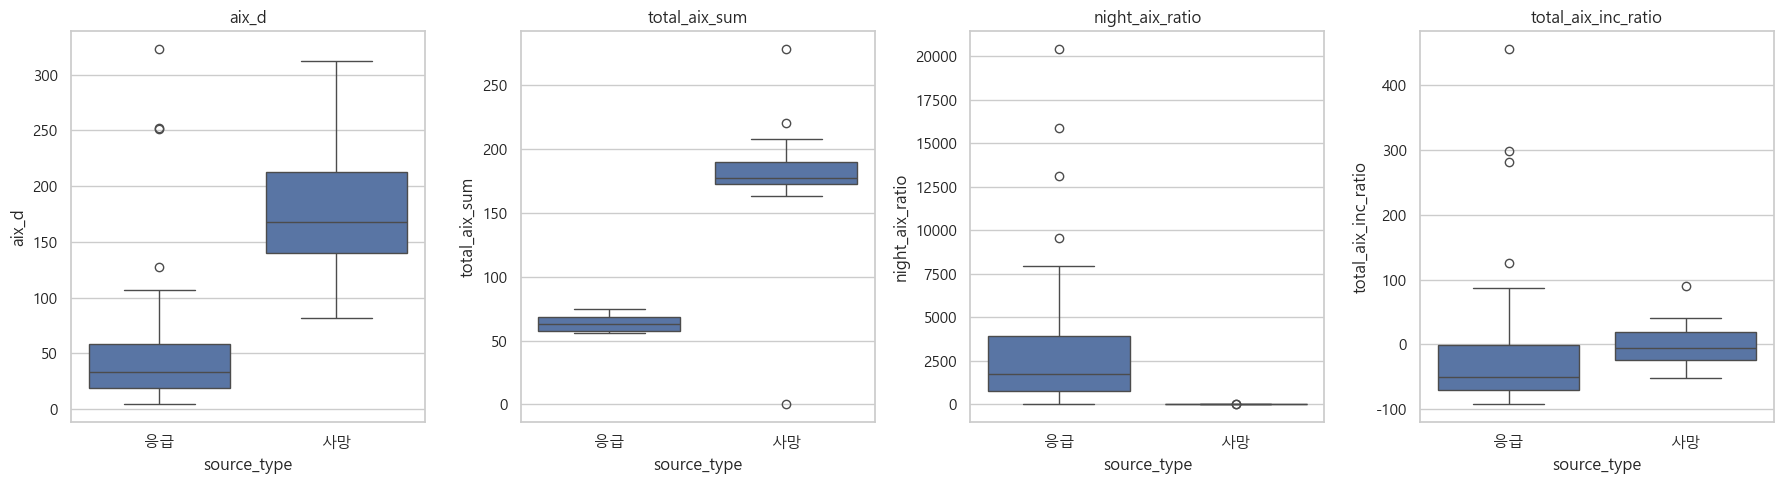

source_type                        사망            응급
aix_d               count   30.000000     30.000000
                    mean   180.566667     63.500000
                    std     51.492673     78.149613
                    min     82.000000      4.000000
                    25%    139.750000     19.000000
                    50%    168.000000     33.000000
                    75%    213.000000     58.500000
                    max    312.000000    323.000000
total_aix_sum       count   30.000000     30.000000
                    mean   178.766667     63.333333
                    std     40.236956      5.949983
                    min      0.000000     56.000000
                    25%    172.250000     57.250000
                    50%    177.500000     63.000000
                    75%    189.500000     68.750000
                    max    278.000000     75.000000
night_aix_ratio     count   30.000000     30.000000
                    mean     5.866667   3583.966667
                    std      3.181122   5001.543634
                    min      0.000000      0.000000
                    25%      4.000000    764.250000
                    50%      5.500000   1746.500000
                    75%      7.000000   3944.000000
                    max     15.000000  20417.000000
total_aix_inc_ratio count   30.000000     30.000000
                    mean    -2.433333      3.066667
                    std     30.088013    129.073070
                    min    -52.000000    -93.000000
                    25%    -23.750000    -71.000000
                    50%     -5.500000    -50.000000
                    75%     19.500000     -1.250000
                    max     90.000000    456.000000

In [7]:
aix_cols = ["aix_d", "total_aix_sum", "night_aix_ratio", "total_aix_inc_ratio"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, aix_cols):
    sns.boxplot(data=df, x="source_type", y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

display(df.groupby("source_type")[aix_cols].describe().T)

## 8. 수면·목욕·외출 피처 — 응급 vs 사망 비교

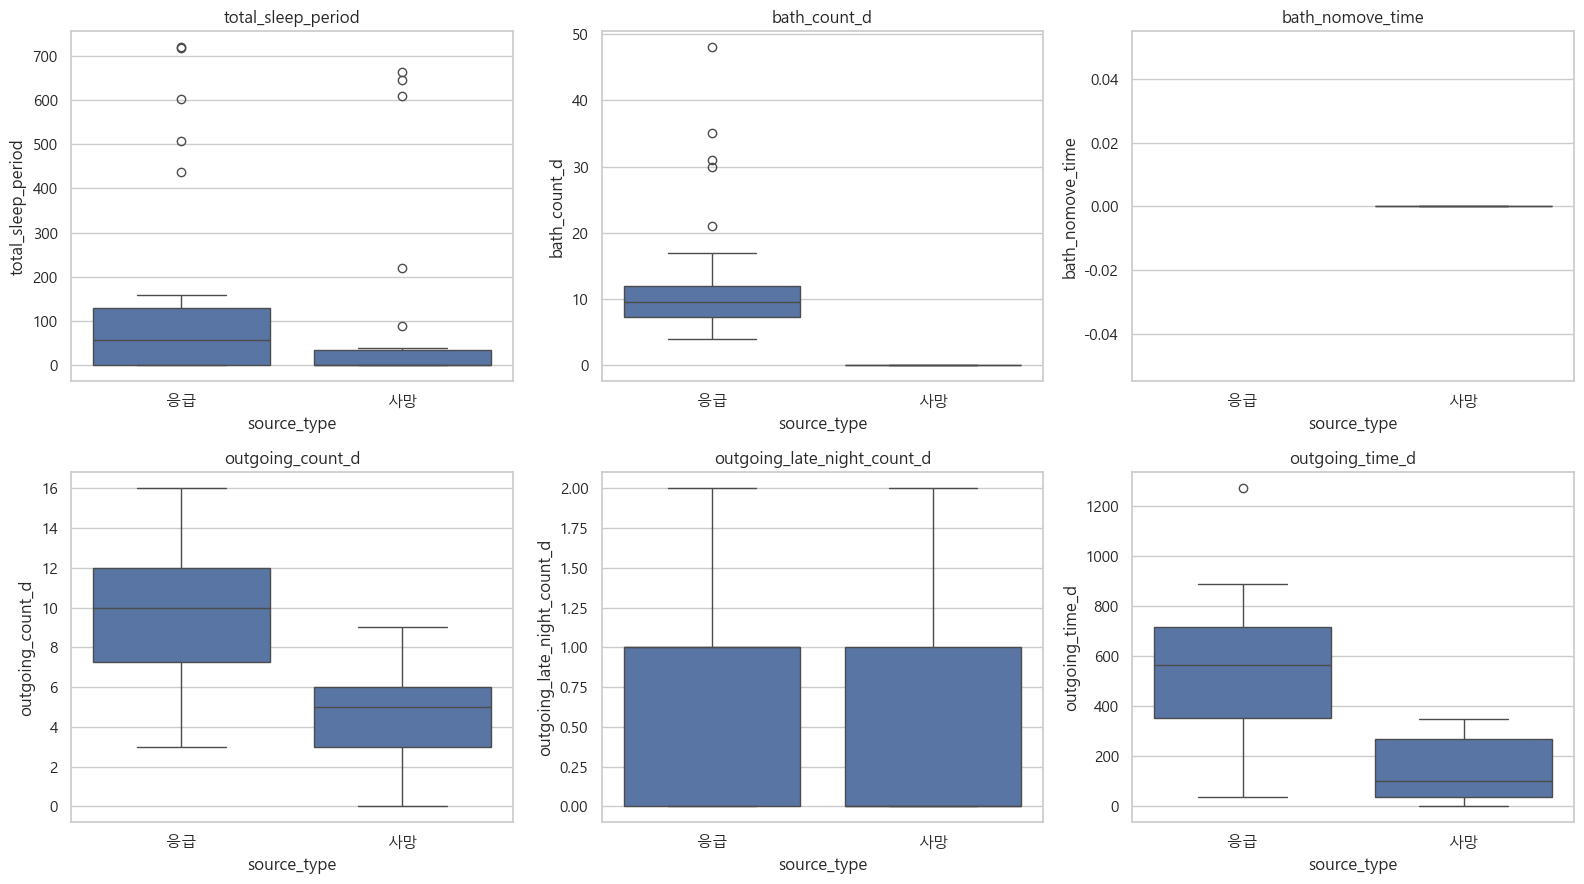

=== source_type별 평균 ===


,total_sleep_period,bath_count_d,bath_nomove_time,outgoing_count_d,outgoing_late_night_count_d,outgoing_time_d
source_type,,,,,,
사망,82.83,0.0,0.0,4.7,0.47,145.77
응급,140.47,13.0,NaN,9.8,0.60,549.07


In [8]:
feat_cols = [
    "total_sleep_period",
    "bath_count_d",
    "bath_nomove_time",
    "outgoing_count_d",
    "outgoing_late_night_count_d",
    "outgoing_time_d",
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, feat_cols):
    sns.boxplot(data=df, x="source_type", y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

print("=== source_type별 평균 ===")
display(df.groupby("source_type")[feat_cols].mean().round(2))

## 9. 24시간 프로파일 — 시간대별 평균 곡선

`aix_h_list`·`temp_list`·`humi_list`·`illu_list` 는 셀마다 24-길이 배열이다.
행들을 stack 해 시간대(0~23시)별 평균을 구하고 응급/사망을 겹쳐 그린다.

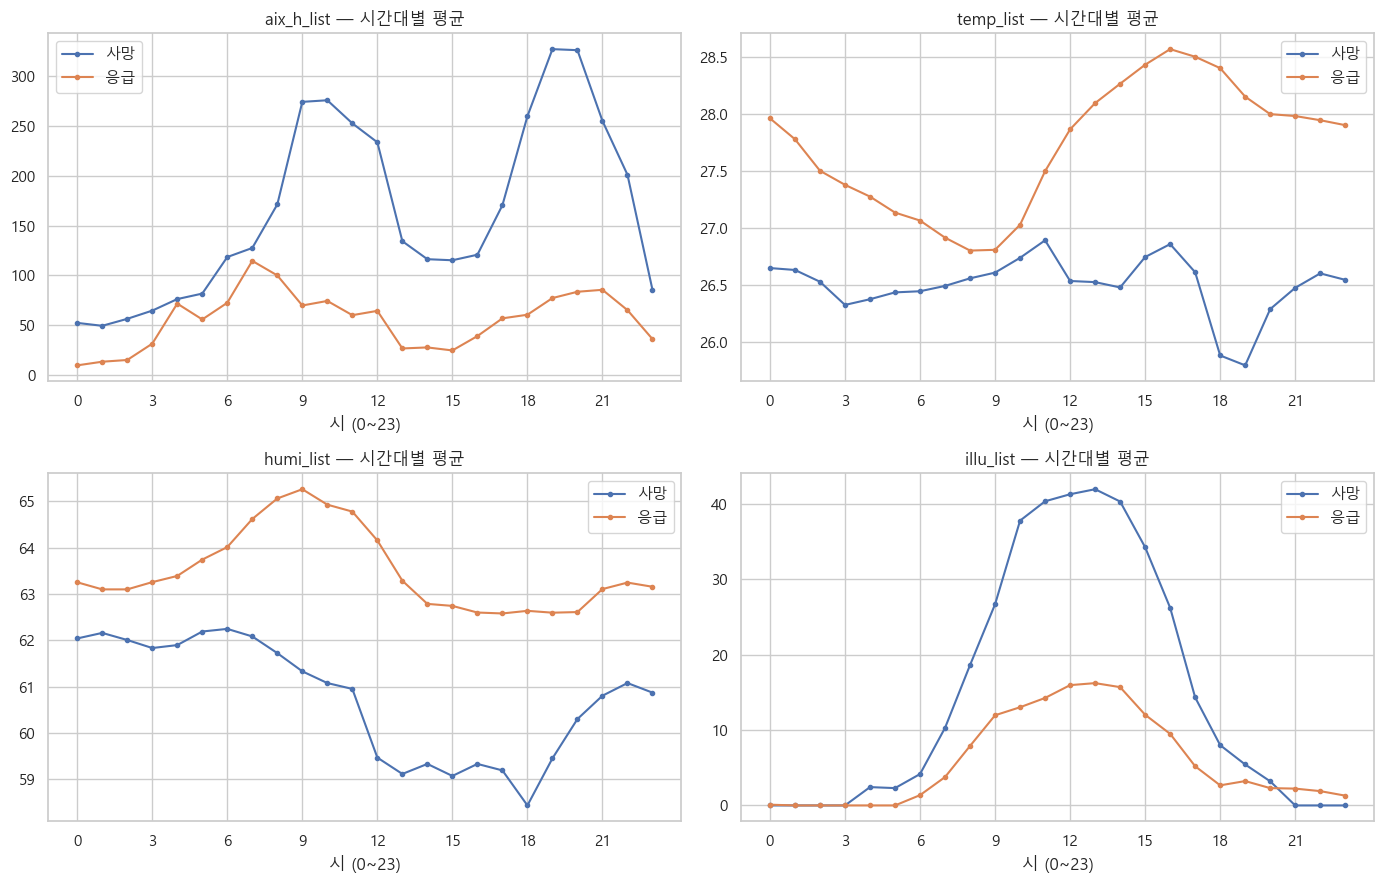

In [9]:
def hourly_mean(series: pd.Series) -> np.ndarray | None:
    """list 컬럼(24-길이 배열)을 stack 해 시간대별 평균을 반환."""
    arrs = [
        np.array(v, dtype=float)
        for v in series.dropna()
        if isinstance(v, list) and len(v) == 24
    ]
    if not arrs:
        return None
    return np.nanmean(np.vstack(arrs), axis=0)


list_cols = ["aix_h_list", "temp_list", "humi_list", "illu_list"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
hours = np.arange(24)

for ax, col in zip(axes.flat, list_cols):
    for stype, group in df.groupby("source_type"):
        prof = hourly_mean(group[col])
        if prof is not None:
            ax.plot(hours, prof, marker="o", markersize=3, label=str(stype))
    ax.set_title(f"{col} — 시간대별 평균")
    ax.set_xlabel("시 (0~23)")
    ax.set_xticks(range(0, 24, 3))
    ax.legend()

plt.tight_layout()
plt.show()

## 10. 연결 종료

In [10]:
await Tortoise.close_connections()
print("DB 연결 종료")

DB 연결 종료
